<a href="https://colab.research.google.com/github/RajShreyaa/1BM23CS317_ML_LAB/blob/main/1BM23CS317_ML_Lab7(SVM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# FUNCTION TO TRAIN SVM

def run_svm(dataset_name):

    print("\n==============================")
    print("Dataset:", dataset_name)
    print("==============================")

    # Load dataset
    data = pd.read_csv(dataset_name)

    # Encode categorical columns
    label_encoder = LabelEncoder()

    for column in data.columns:
        if data[column].dtype == 'object':
            data[column] = label_encoder.fit_transform(data[column])

    # Last column = target (automatic fix)
    X = data.iloc[:, :-1]
    y = data.iloc[:, -1]

    # 80 / 20 split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # Linear Kernel

    svm_linear = SVC(kernel='linear')

    svm_linear.fit(X_train, y_train)

    y_pred_linear = svm_linear.predict(X_test)

    print("\n--- Linear Kernel ---")

    print("Accuracy:",
          accuracy_score(y_test, y_pred_linear))

    print("Confusion Matrix:")

    print(confusion_matrix(
        y_test,
        y_pred_linear
    ))

    # RBF Kernel

    svm_rbf = SVC(kernel='rbf')

    svm_rbf.fit(X_train, y_train)

    y_pred_rbf = svm_rbf.predict(X_test)

    print("\n--- RBF Kernel ---")

    print("Accuracy:",
          accuracy_score(y_test, y_pred_rbf))

    print("Confusion Matrix:")

    print(confusion_matrix(
        y_test,
        y_pred_rbf
    ))


# RUN FOR BOTH DATASETS

run_svm("iris (1) (2).csv")

run_svm("drug.csv")


Dataset: iris (1) (2).csv

--- Linear Kernel ---
Accuracy: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

--- RBF Kernel ---
Accuracy: 1.0
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Dataset: drug.csv

--- Linear Kernel ---
Accuracy: 1.0
Confusion Matrix:
[[ 6  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 11  0]
 [ 0  0  0  0 15]]

--- RBF Kernel ---
Accuracy: 0.625
Confusion Matrix:
[[ 0  0  0  6  0]
 [ 0  0  0  3  0]
 [ 0  0  0  4  1]
 [ 0  0  0 10  1]
 [ 0  0  0  0 15]]


Accuracy: 0.9305

Confusion Matrix:
[[144   0   1   0   0   0   1   0   0   0   1   0   1   0   0   0   0   0
    0   0   1   0   0   0   0   0]
 [  0 143   0   5   0   1   0   0   0   0   0   0   0   0   0   0   0   4
    0   0   0   0   0   0   0   0]
 [  0   0 123   0   2   0   3   1   0   0   1   0   0   0   4   0   0   2
    0   0   1   0   0   0   0   0]
 [  0   1   0 153   0   0   0   2   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   3   1   0 130   0   5   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   1]
 [  0   2   0   0   1 134   0   0   1   0   0   0   0   0   0   0   0   0
    1   1   0   0   0   0   0   0]
 [  1   0   1   4   0   0 149   0   0   0   2   0   0   0   0   0   0   2
    0   0   0   1   0   0   0   0]
 [  0   4   0   8   0   0   0 106   0   0   5   0   0   1   2   1   1  13
    0   0   2   0   0   0   1   0]
 [  0   0   0   1   0   2   0   0 134   7   0   0   0   0   0   0   0   0
    0   0   0   0 

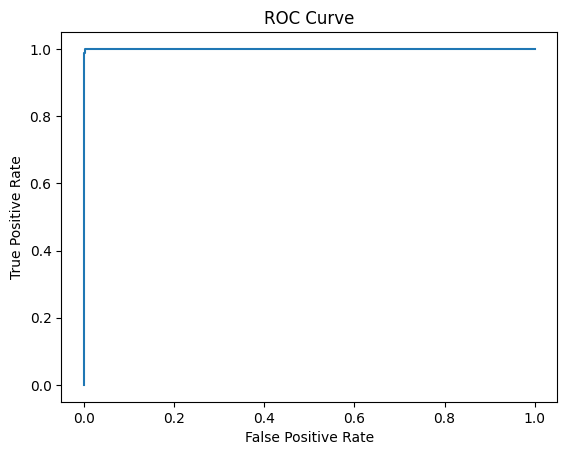

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Load dataset
data = pd.read_csv("letter-recognition.csv")

# First column is the target (Letter)
X = data.iloc[:, 1:]
y = data.iloc[:, 0]

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train SVM model (RBF kernel)
svm_model = SVC(kernel='rbf', probability=True)

svm_model.fit(X_train, y_train)

# Predictions
y_pred = svm_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# ROC Curve and AUC

# Convert labels to binary format
classes = sorted(y.unique())

y_test_bin = label_binarize(y_test, classes=classes)

# Get probability scores
y_score = svm_model.predict_proba(X_test)

# Compute ROC and AUC for first class
fpr, tpr, thresholds = roc_curve(
    y_test_bin[:, 0],
    y_score[:, 0]
)

roc_auc = auc(fpr, tpr)

print("\nAUC Score:", roc_auc)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()